## **NextWave 데이터 처리**

#### 데이터 출처 : 공모전 제공 데이터셋 ( NextWave 비즈니스 케이스 )


1. PDF 내 요약 표 데이터를 Python 데이터프레임으로 수동 구조화 
2. 퍼널 분석 및 세그먼트별 리텐션 분석을 위한 데이터 정제
3. 시각화 및 가설 검증을위한 기초 데이터 마트 구축

In [2]:
import pandas as pd
import numpy as np

##  데이터 수집 및 구조화

**1. funnel_summary.csv 데이터 생성**


In [3]:
funnel_data={
    "month":["1월","2월","3월","4월"],
    "방문 유저 수":[52000,54000,55500,56000],
    "회원가입 유저":[4420,4212,3885,3528],
    "무료 체험 유저":[2431,2274,1942,1623],
    "유료 결제 유저":[972,880,731,584],
    "한달 유지":[1945,1801,1492,1176]
}
df_funnel=pd.DataFrame(funnel_data)
df_funnel

,month,방문 유저 수,회원가입 유저,무료 체험 유저,유료 결제 유저,한달 유지
0,1월,52000,4420,2431,972,1945
1,2월,54000,4212,2274,880,1801
2,3월,55500,3885,1942,731,1492
3,4월,56000,3528,1623,584,1176


**2. channel_performance.csv 데이터 생성**

In [4]:
channel_data={
    "유입 채널": ["검색", "SNS", "자연 유입", "지인 추천"],
    "방문자 수": [18000, 17500, 11000, 9500],
    "회원가입 전환율": ["8.1%", "4.3%", "9.5%", "10.2%"],
    "무료체험 시작률": ["5.0%", "2.1%", "6.4%", "7.1%"],
    "유료 전환율": ["1.8%", "0.7%", "2.2%", "2.8%"]
}
df_channel = pd.DataFrame(channel_data)
df_channel

,유입 채널,방문자 수,회원가입 전환율,무료체험 시작률,유료 전환율
0,검색,18000,8.1%,5.0%,1.8%
1,SNS,17500,4.3%,2.1%,0.7%
2,자연 유입,11000,9.5%,6.4%,2.2%
3,지인 추천,9500,10.2%,7.1%,2.8%


**3. landing_event_log.csv 데이터 생성**

In [5]:
landing_data = {
    "단계": ["랜딩페이지 진입", "회원가입 CTA 클릭", "회원정보 입력 시작", "이메일 인증 완료", "가입 완료"],
    "사용자 수": [56000, 14560, 9920, 4830, 3528],
    "이탈률": ["0%", "74.0%", "31.9%", "51.3%", "27.0%"]
}
df_landing = pd.DataFrame(landing_data)
df_landing

,단계,사용자 수,이탈률
0,랜딩페이지 진입,56000,0%
1,회원가입 CTA 클릭,14560,74.0%
2,회원정보 입력 시작,9920,31.9%
3,이메일 인증 완료,4830,51.3%
4,가입 완료,3528,27.0%


**4. trial_usage_summary.csv 데이터 생성**

In [6]:
trial_data = {
    "기능": ["일정관리", "협업메모", "팀 초대", "알림 자동화"],
    "기능 사용자 수": [2840, 1920, 740, 510],
    "평균 사용 횟수": [8.2, 4.1, 2.7, 1.9],
    "유료 전환율": ["24.0%", "17.5%", "36.0%", "41.0%"]
}
df_trial = pd.DataFrame(trial_data)
df_trial

,기능,기능 사용자 수,평균 사용 횟수,유료 전환율
0,일정관리,2840,8.2,24.0%
1,협업메모,1920,4.1,17.5%
2,팀 초대,740,2.7,36.0%
3,알림 자동화,510,1.9,41.0%


**5. segment_retention.csv 데이터 생성**

In [7]:
segment_data = {
    "고객 유형": ["대학생", "직장인 개인사용자", "프리랜서", "소규모 팀 사용자"],
    "4주차 유지율": ["21%", "38%", "34%", "49%"]
}
df_segment = pd.DataFrame(segment_data)
df_segment

,고객 유형,4주차 유지율
0,대학생,21%
1,직장인 개인사용자,38%
2,프리랜서,34%
3,소규모 팀 사용자,49%


**6. customer_feedback.csv 데이터 생성**

In [8]:
feedback_data = {
    "이슈 유형": ["가입 절차 번거로움", "가치 체감 부족", "요금제 이해 어려움", "기능 이해 부족", "알림 과다"],
    "비중": ["28%", "24%", "18%", "16%", "14%"]
}
df_feedback = pd.DataFrame(feedback_data)
df_feedback

,이슈 유형,비중
0,가입 절차 번거로움,28%
1,가치 체감 부족,24%
2,요금제 이해 어려움,18%
3,기능 이해 부족,16%
4,알림 과다,14%


태스크 설명
- 분산된 PDF 정보를 JUPYTER NOTEBOOK 환경에서 Python을 활용하여 테이블 생성함.

In [9]:
def clean_percent(column):
    return column.str.replace('%','').astype(float)/100

df_channel['회원가입 전환율']=clean_percent(df_channel['회원가입 전환율'])
df_channel['무료체험 시작률']=clean_percent(df_channel['무료체험 시작률'])
df_channel['유료 전환율']=clean_percent(df_channel['유료 전환율'])

df_landing['이탈률']=clean_percent(df_landing['이탈률'])

df_trial['유료 전환율']=clean_percent(df_trial['유료 전환율'])

df_segment['4주차 유지율']=clean_percent(df_segment['4주차 유지율'])

df_feedback['비중']=clean_percent(df_feedback['비중'])

In [10]:
df_channel.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   유입 채널     4 non-null      str    
 1   방문자 수     4 non-null      int64  
 2   회원가입 전환율  4 non-null      float64
 3   무료체험 시작률  4 non-null      float64
 4   유료 전환율    4 non-null      float64
dtypes: float64(3), int64(1), str(1)
memory usage: 292.0 bytes


# EDA 

### **channel_performance 시각화 및 인사이트 도출** ###

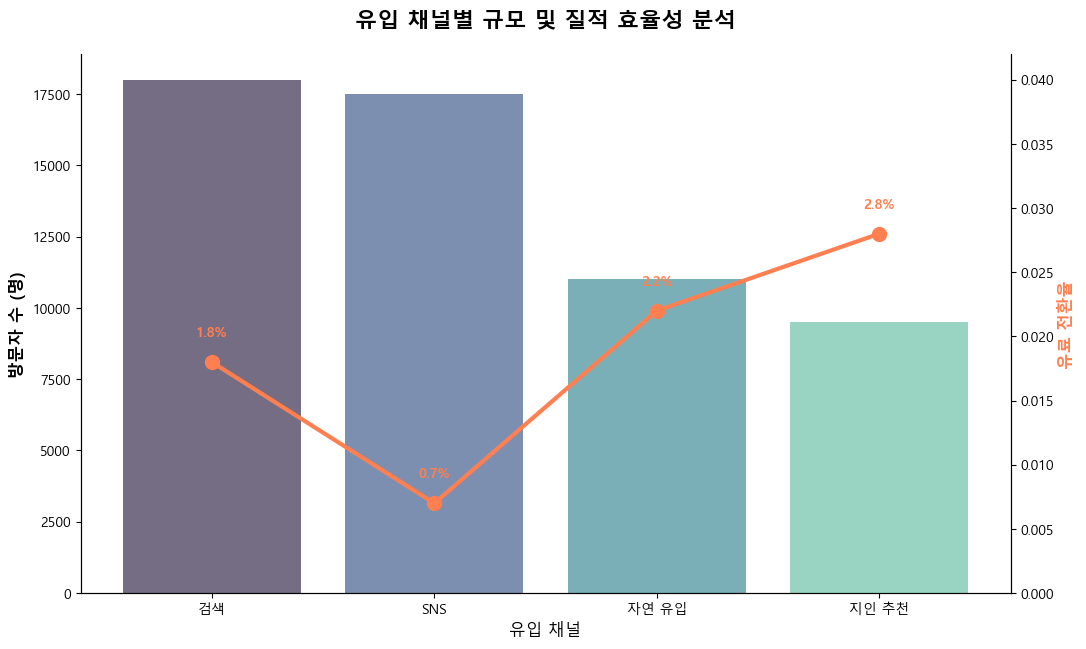

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc

# 환경 설정 (폰트 및 스타일)
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 데이터 시각화 설정 (이중 축 그래프)
fig, ax1 = plt.subplots(figsize=(12, 7))

# 톤다운된 차분한 컬러 팔레트 적용
unified_colors = sns.color_palette("mako", len(df_channel))

# [왼쪽 축] 방문자 수 (막대 그래프)
ax1 = sns.barplot(
    x='유입 채널', 
    y='방문자 수', 
    data=df_channel, 
    palette=unified_colors,
    hue='유입 채널',
    legend=False,
    alpha=0.7,
    ax=ax1
)
ax1.set_ylabel('방문자 수 (명)', fontsize=12, fontweight='bold')
ax1.set_xlabel('유입 채널', fontsize=12)

# [오른쪽 축] 유료 전환율 (선 그래프)
ax2 = ax1.twinx() # x축을 공유하는 두 번째 y축 생성
ax2.plot(df_channel['유입 채널'], df_channel['유료 전환율'], color='coral', marker='o', linewidth=3, markersize=10, label='유료 전환율')
ax2.set_ylabel('유료 전환율', fontsize=12, color='coral', fontweight='bold')
ax2.set_ylim(0, df_channel['유료 전환율'].max() * 1.5) # 수치 비교가 용이하도록 범위 설정

# 수치 표시 (전환율)
for i, val in enumerate(df_channel['유료 전환율']):
    ax2.text(i, val + 0.002, f'{val*100:.1f}%', color='coral', ha='center', fontweight='bold')

plt.title('유입 채널별 규모 및 질적 효율성 분석', fontsize=16, pad=20, fontweight='bold')
sns.despine(right=False)

plt.show()

## **NextWave 유입 채널별 방문자 수 및 전활율 비교 분석**  

**1. 지인 추천 채널의 압도적 질적 우위**
- `지인 추천` 채널은 전체 유입 규모가 가장 작음에도 불구하고, `유료 전환율은 가장 높은 수치` 기록.
- 인사이트 : 서비스 가치가 이미 검증된 유저들이 유입되고 있다는 증거

**2. SNS 채널의 양적 팽창과 낮은 효율**
- `SNS` 채널은 많은 방문자 수를 기록하고 있으나 유료 전환율은 타 채널 대비 현저히 낮음.
- 인사이트 : 광고 타켓팅이 너무 광범위하거나, 랜딩 페이지의 메시지가 유저의 실제 필요와 일치하지 않는 `낚시 성 콘텐츠`일 가능성 높음.


### **customer_feedback 시각화 및 인사이트 도출** ###

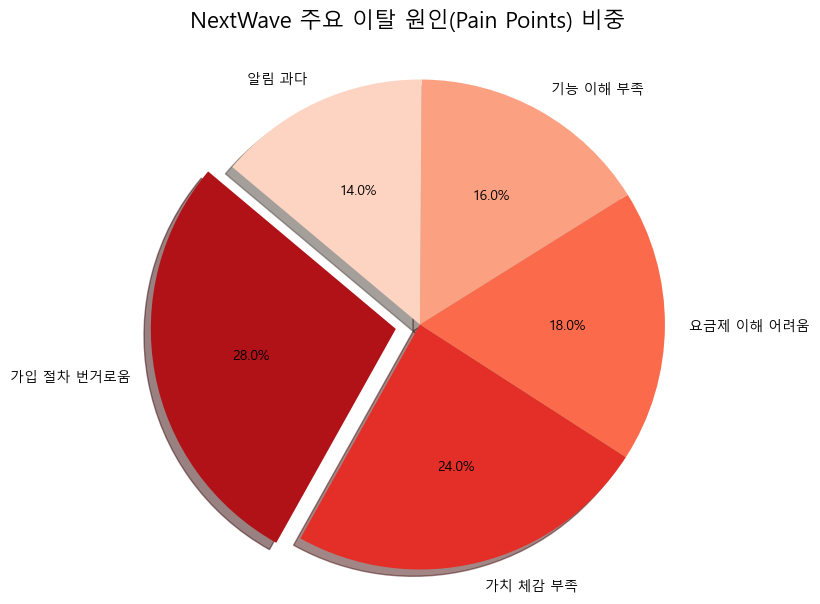

In [12]:
# 분석용 통합 색상 팔레트 정의 (Reds 계열로 통일)
# 짙은 색에서 연한 색 순서로 구성하여 이탈의 심각성을 시각화
unified_colors = sns.color_palette("Reds_r", 5)

# --- [시각화 1] 이슈 유형별 비중 파이 차트 ---
# NextWave 유저들이 느끼는 '주관적 불만'의 원인을 분석
plt.figure(figsize=(10, 7))

# 데이터 준비 (df_feedback 사용)
labels_pie = df_feedback['이슈 유형']
sizes_pie = df_feedback['비중']  # clean_percent가 적용된 실수형 데이터

# 가장 비중이 큰 '가입 절차 번거로움' 조각을 강조 (Explode)
explode = [0.1 if s == sizes_pie.max() else 0 for s in sizes_pie]

plt.pie(sizes_pie, 
        explode=explode, 
        labels=labels_pie, 
        autopct='%1.1f%%', 
        startangle=140, 
        shadow=True, 
        colors=unified_colors)

plt.title('NextWave 주요 이탈 원인(Pain Points) 비중', fontsize=16, pad=20)
plt.axis('equal') 

plt.show()

## **NextWave 이슈 유형별 비중 파이 차트 해석**  
### **NextWave 페인 포인트** ###

**1. '입구 병목' 현상과 이탈 골든타임 도출**
- `가입 절차 번거로움` (28%)이 1위
- 인사이트 : 유저가 서비스의 본질적인 가치를 경험하기도 전에  `온보딩(초기 진입)` 단계에서 지쳐 떠남.

#### 서비스 기능의 문제가 아니라 `UX/UI 접근성`의 문제이며, ####
#### 이 단계의 이탈을 막는 것이 전체 리텐션 개선의 빠른 지름길 ####

**2. '가치 체감 부족'과 연계된 기능 우선순위 설정**
- `가치 체감 부족` (24%) 과 `기능 이해 부족` (16%) 을 합치면 40%.
- 인사이트 : 유저들이 "이 서비스가 나한테 왜 필요한지 모르겠다" 라고 느낌. 이는 튜토리얼이나 메인 대시보드에서 핵심 가치를 보여주는 방식이 잘못됨을 시사함.

#### 유저들에게 서비스의 `Aha-Moment(핵심 가치를 느끼는 순간)`를 전달하는데 실패하고 있음. ####
#### 단순 기능 추가보다는 기존 기능의 `활용 가이드` 강화가 시그 ####

**3. '알림과다'를 통한 세그먼트별 대응 전략**
- `알림과다` (14%) 는 비중은 낮지만 특정 유저층에게 치명적인 이탈사유
- 인사이트 : 모든 유저에게 일괄적으로 보내는 푸시 알림이나 메일이 오히려 피로도를 높여 앱 삭제를 유도할 것임.

#### 이탈 사유 중 `알림 과다`가 유의미한 비중을 차지하며, 유저 활동성에 따른 `개인화 알림 설정` 기능이 부재할 경우, 활동량이 높은 헤비 유저초자 피로도로 인해 이탈 가능성이 있음. ####

### **landing_event_log 시각화 및 인사이트 도출** ###

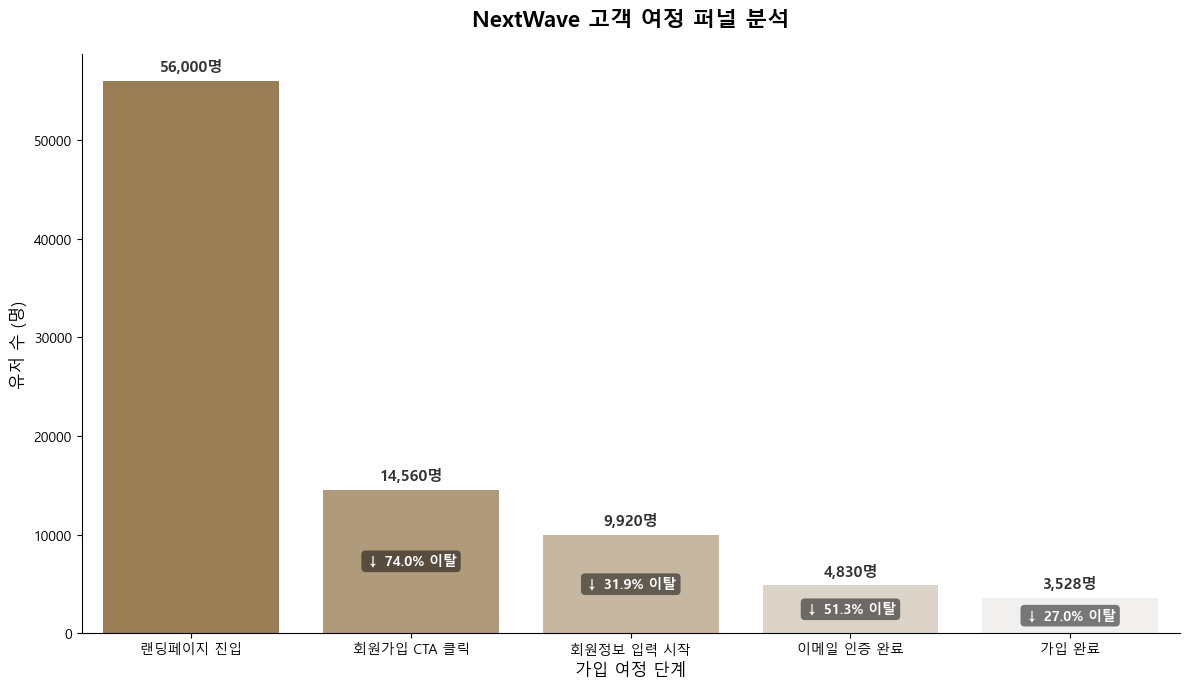

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc

# 윈도우 폰트 설정 (맑은 고딕)
font_path = "C:/Windows/Fonts/malgun.ttf" 
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 그래프 생성
plt.figure(figsize=(12, 7))

custom_color = "#a47f48"
pal = sns.light_palette(custom_color, n_colors=len(df_landing), reverse=True)
# -----------------------

# 막대 그래프 그리기
ax = sns.barplot(
    x='단계', 
    y='사용자 수', 
    data=df_landing, 
    palette=pal, 
    hue='단계',    
    legend=False
)

# 데이터 라벨링 (막대 위에 수치 및 이탈률 표시)
for i, p in enumerate(ax.patches):
    # 현재 단계 사용자 수
    user_count = int(p.get_height())
    # 현재 단계 이탈률 (df_landing의 '이탈률' 컬럼 활용)
    # 데이터프레임 구조에 따라 loc 또는 iloc를 사용합니다.
    drop_rate = df_landing.iloc[i]['이탈률'] * 100
    
    # 막대 위에 사용자 수 표시
    ax.annotate(f'{user_count:,}명', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold', color='#333333')
    
    # 이탈률이 0보다 큰 경우에만 이탈률 표시 (검은색 반투명 박스로 가독성 확보)
    if drop_rate > 0:
        ax.annotate(f'↓ {drop_rate:.1f}% 이탈', 
                    (p.get_x() + p.get_width() / 2., p.get_height() / 2), 
                    ha = 'center', va = 'center', 
                    color='white', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", fc="black", ec="none", alpha=0.5))

# 그래프 제목 및 축 설정
plt.title('NextWave 고객 여정 퍼널 분석', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('유저 수 (명)', fontsize=12)
plt.xlabel('가입 여정 단계', fontsize=12)

# 테두리 정리
sns.despine()
plt.tight_layout()

plt.show()

## **NextWave 고객 여정 퍼널 분석차트 해석**  


**1. `더블 드롭` 현상**

- `1차 절벽` : `(CTA 클릭)`> `(입력 시작)` 회원가입 버튼을 누른 후 실제 정보를 입력하기 시작하는 유저가 급감함(74.0%) . 이는 가입 페이지의 UX가 너무 복잡하거나, 요구하는 정보가 너무 많아 유저가 심리적 부담을 느꼈음을 알 수 있음.
- `2차 절벽` : `(입력시작)`> `(이메일 인증 완료)` 정보를 다 입력하고도 이메일 인증 단계에서 다시 절반 이상(51.3%)이 이탈함. 이는 인증 메일 발송 지연이나 스팸 분류 등 기술적 결함이 있을 가능성이 매우 높음을 보여줌.

### 앞서 분석한 파이 차트 결과와 일치. 유저들은 `가입 절차 번거로움` 을 가장 큰 불만으로 꼽음. 퍼널 분석 결과, 실제로 이메일 인증 단계와 그 전후 과정에서 유저의 약 90% 사라짐 ###
### **VOC가 실제 이탈 수치로 완벽 증명. 이 문제 해결이 리텐션 개선의 1순위**

### **trial_usage_summary 시각화 및 인사이트 도출** ###

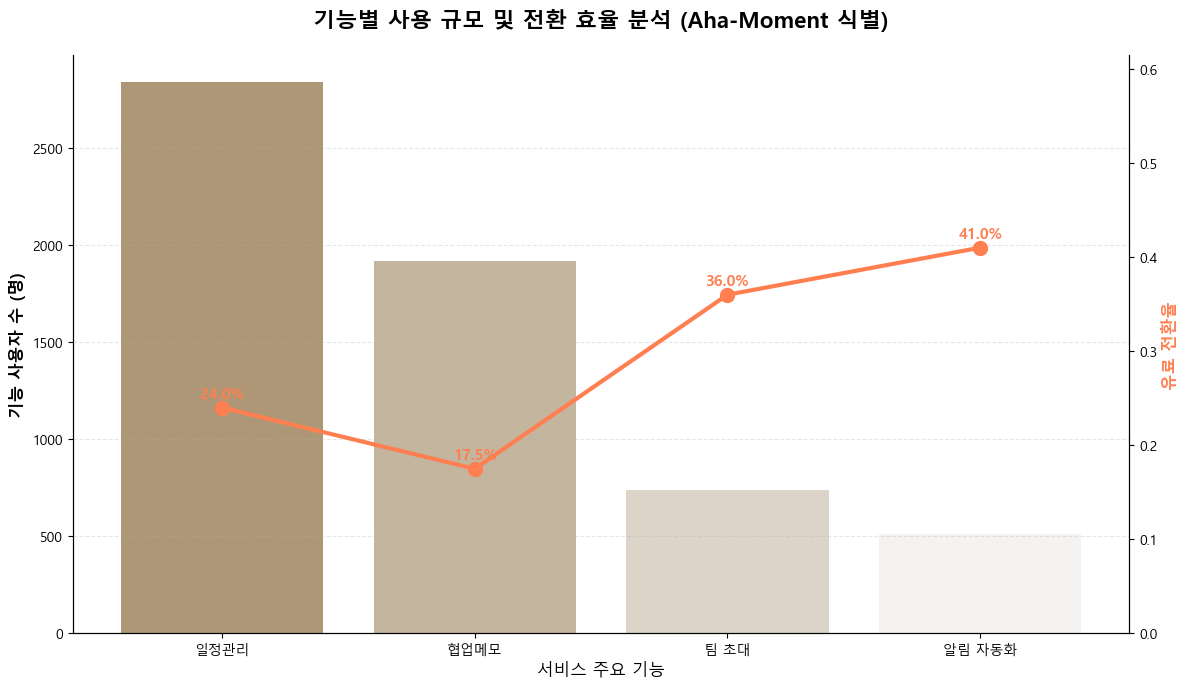

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc

# 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 데이터 시각화 설정 (이중 축 그래프)
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- 색상 설정 변경 ---
# 요청하신 #a47f48 색상을 사용하여 단일 톤의 팔레트 생성
# 모든 막대를 같은 색으로 하려면 palette 대신 color='#a47f48'을 사용하세요.
target_color = "#a47f48"
unified_colors = sns.light_palette(target_color, n_colors=len(df_trial), reverse=True)
# --------------------

# [왼쪽 축] 기능 사용자 수 (막대 그래프)
ax1 = sns.barplot(
    x='기능', 
    y='기능 사용자 수', 
    data=df_trial, 
    palette=unified_colors, # 변경된 브라운 톤 팔레트 적용
    hue='기능',
    legend=False,
    alpha=0.8, # 조금 더 선명하게 조정
    ax=ax1
)
ax1.set_ylabel('기능 사용자 수 (명)', fontsize=12, fontweight='bold')
ax1.set_xlabel('서비스 주요 기능', fontsize=12)

# [오른쪽 축] 유료 전환율 (선 그래프)
ax2 = ax1.twinx() 
ax2.plot(df_trial['기능'], df_trial['유료 전환율'], color='coral', marker='o', linewidth=3, markersize=10, label='유료 전환율')
ax2.set_ylabel('유료 전환율', fontsize=12, color='coral', fontweight='bold')
ax2.set_ylim(0, df_trial['유료 전환율'].max() * 1.5) 

# 수치 표시 (전환율 %)
for i, val in enumerate(df_trial['유료 전환율']):
    ax2.text(i, val + 0.01, f'{val*100:.1f}%', color='coral', ha='center', fontweight='bold', fontsize=11)

plt.title('기능별 사용 규모 및 전환 효율 분석 (Aha-Moment 식별)', fontsize=16, pad=20, fontweight='bold')

# 테두리 및 그리드 미세 조정
sns.despine(right=False)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## **NextWave 기능별 사용 규모 및 전환 효율 분석**  

**1. 대중성 vs 수익성의 극명한 차이**
- `일정관리` : 가장 많은 유저가 사용하지만 전환율은 평균적. 이는 유저들이 가장 먼저 접하는 기본 기능임.
- `알림 자동화` :  사용자는 가장 적지만, 일단 쓰면 41%가 결제함. 이는 알림 자동화 기능이 유저가 돈을 내게 만드는 킬러 기능임.


### **segment_retention 시각화 및 인사이트 도출** ###

In [ ]:
# 데이터 준비 및 정렬 (유지율이 높은 순서대로)
df_segment_sorted = df_segment.sort_values(by='4주차 유지율', ascending=False)

# 시각화 설정
plt.figure(figsize=(12, 7))

# --- 색상 설정 변경 ---
# 요청하신 #a47f48 색상을 사용하여 그라데이션 팔레트 생성
target_color = "#a47f48"
unified_colors = sns.light_palette(target_color, n_colors=len(df_segment_sorted), reverse=True)
# --------------------

# 막대 그래프 그리기
ax = sns.barplot(
    x='고객 유형', 
    y='4주차 유지율', 
    data=df_segment_sorted, 
    palette=unified_colors, # 브라운 톤 적용
    hue='고객 유형',
    legend=False,
    alpha=0.8
)

# 수치 표시 (유지율 %)
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold', color='#333333')

plt.title('고객 세그먼트별 4주차 유지율 분석 (타겟 고객 식별)', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('4주차 유지율 (1.0 = 100%)', fontsize=12)
plt.ylim(0, 1.1) # 레이블이 잘리지 않도록 상단을 살짝 여유 있게 설정 (1.0 -> 1.1)
sns.despine()

# 이미지 자동 저장
plt.savefig('nextwave_05_segment_efficiency.png', dpi=300, bbox_inches='tight')
plt.show()